In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report
import warnings

# specific to Jupyter Notebook to display plots inline
%matplotlib inline

import matplotlib.pyplot as plt

# Common sklearn modules for model building

warnings.filterwarnings('ignore')

In [3]:
file1=r"C:\Users\Shakil Ahmad\OneDrive\Desktop\UIDAI\Adhar Analysis\01_data\raw\enrollement\api_data_aadhar_enrolment_0_500000.csv"
file2=r"C:\Users\Shakil Ahmad\OneDrive\Desktop\UIDAI\Adhar Analysis\01_data\raw\enrollement\api_data_aadhar_enrolment_500000_1000000.csv"
file3=r"C:\Users\Shakil Ahmad\OneDrive\Desktop\UIDAI\Adhar Analysis\01_data\raw\enrollement\api_data_aadhar_enrolment_1000000_1006029.csv"

In [4]:
df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)
df3 = pd.read_csv(file3)


In [5]:
print("File 1 shape:", df1.shape)
print("File 2 shape:", df2.shape)
print("File 3 shape:", df3.shape)


File 1 shape: (500000, 7)
File 2 shape: (500000, 7)
File 3 shape: (6029, 7)


In [6]:
df = pd.concat([df1, df2, df3], axis=0, ignore_index=True)
print("Merged dataset shape:", df.shape)

Merged dataset shape: (1006029, 7)


In [7]:
before_dup = df.shape[0]
df.drop_duplicates(inplace=True)
after_dup = df.shape[0]

In [8]:
print(f"Duplicates removed: {before_dup - after_dup}")
enrolment_df = df.copy()



Duplicates removed: 22957


In [9]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

In [10]:
df.head()

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
0,02-03-2025,Meghalaya,East Khasi Hills,793121,11,61,37
1,09-03-2025,Karnataka,Bengaluru Urban,560043,14,33,39
2,09-03-2025,Uttar Pradesh,Kanpur Nagar,208001,29,82,12
3,09-03-2025,Uttar Pradesh,Aligarh,202133,62,29,15
4,09-03-2025,Karnataka,Bengaluru Urban,560016,14,16,21


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 983072 entries, 0 to 1006028
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   date            983072 non-null  object
 1   state           983072 non-null  object
 2   district        983072 non-null  object
 3   pincode         983072 non-null  int64 
 4   age_0_5         983072 non-null  int64 
 5   age_5_17        983072 non-null  int64 
 6   age_18_greater  983072 non-null  int64 
dtypes: int64(4), object(3)
memory usage: 60.0+ MB


In [12]:
df.columns

Index(['date', 'state', 'district', 'pincode', 'age_0_5', 'age_5_17',
       'age_18_greater'],
      dtype='object')

In [13]:
output_path = "merged_clean_aadhaar_enrolment_data.csv"
df.to_csv(output_path, index=False)

print(f"Clean merged dataset saved as: {output_path}")

Clean merged dataset saved as: merged_clean_aadhaar_enrolment_data.csv


In [14]:
# The file was saved in the current directory in the previous step as "merged_clean_aadhaar_enrolment_data.csv"
df = pd.read_csv(
    r"c:\Users\Shakil Ahmad\OneDrive\Desktop\UIDAI\Adhar Analysis\01_data\processed\merged_clean_aadhaar_enrolment_data.csv"
)
df.head()


,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
0,02-03-2025,Meghalaya,East Khasi Hills,793121,11,61,37
1,09-03-2025,Karnataka,Bengaluru Urban,560043,14,33,39
2,09-03-2025,Uttar Pradesh,Kanpur Nagar,208001,29,82,12
3,09-03-2025,Uttar Pradesh,Aligarh,202133,62,29,15
4,09-03-2025,Karnataka,Bengaluru Urban,560016,14,16,21


In [15]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 983072 entries, 0 to 983071
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   date            983072 non-null  object
 1   state           983072 non-null  object
 2   district        983072 non-null  object
 3   pincode         983072 non-null  int64 
 4   age_0_5         983072 non-null  int64 
 5   age_5_17        983072 non-null  int64 
 6   age_18_greater  983072 non-null  int64 
dtypes: int64(4), object(3)
memory usage: 52.5+ MB


In [16]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

missing_df[missing_df["Missing Count"] > 0]


,Missing Count,Missing %


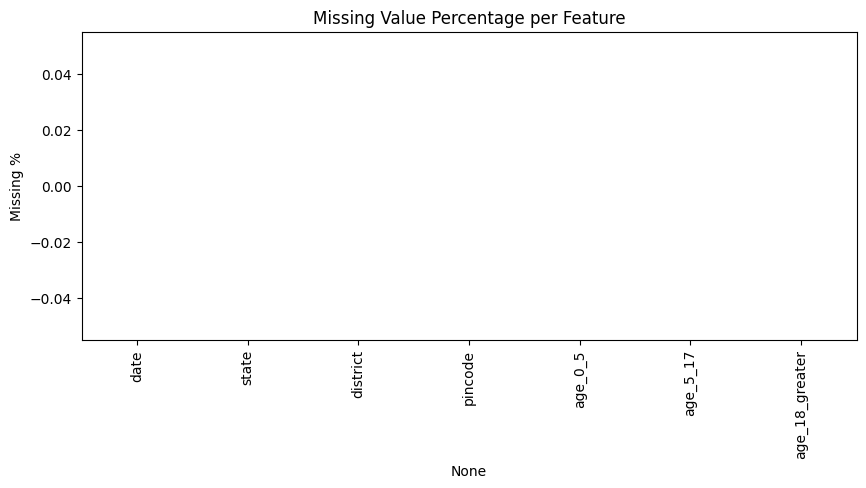

In [17]:
plt.figure(figsize=(10,4))
sns.barplot(x=missing_df.index, y=missing_df["Missing %"])
plt.xticks(rotation=90)
plt.title("Missing Value Percentage per Feature")
plt.show()



In [18]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numerical Features:", len(num_cols))
print("Categorical Features:", len(cat_cols))
print("Numerical Columns:", num_cols.tolist())
print("Categorical Columns:", cat_cols.tolist())


Numerical Features: 4
Categorical Features: 3
Numerical Columns: ['pincode', 'age_0_5', 'age_5_17', 'age_18_greater']
Categorical Columns: ['date', 'state', 'district']


In [19]:
df[num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
pincode,983072.0,518469.318987,205492.403834,100000.0,363621.0,517401.0,700093.0,855456.0
age_0_5,983072.0,3.534216,17.726248,0.0,1.0,2.0,3.0,2688.0
age_5_17,983072.0,1.720026,14.529760,0.0,0.0,0.0,1.0,1812.0
age_18_greater,983072.0,0.169328,3.255971,0.0,0.0,0.0,0.0,855.0


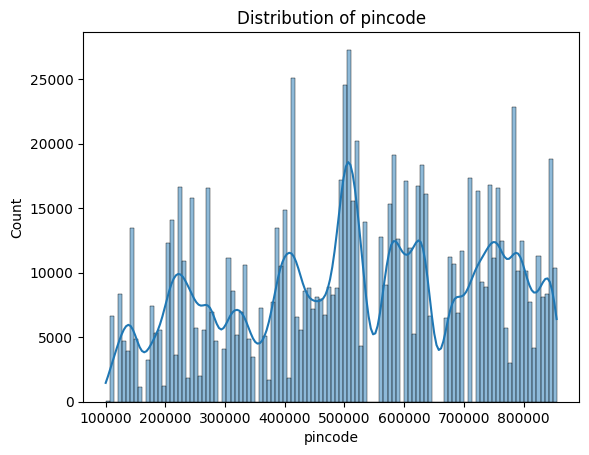

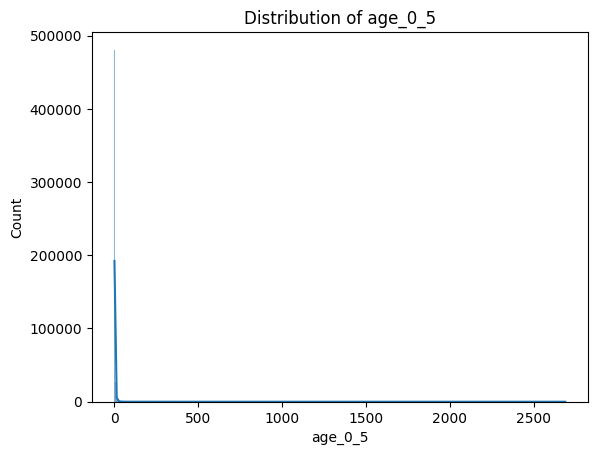

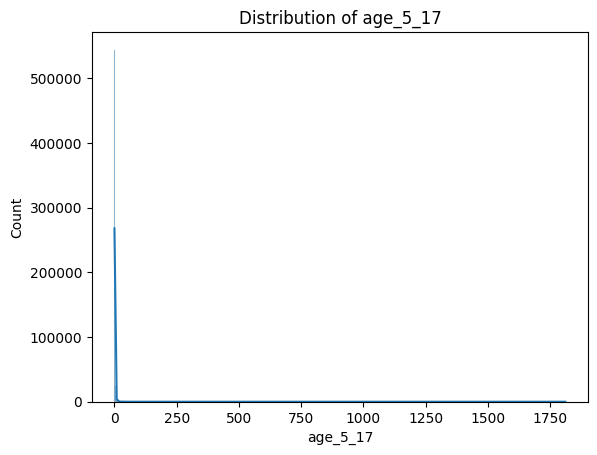

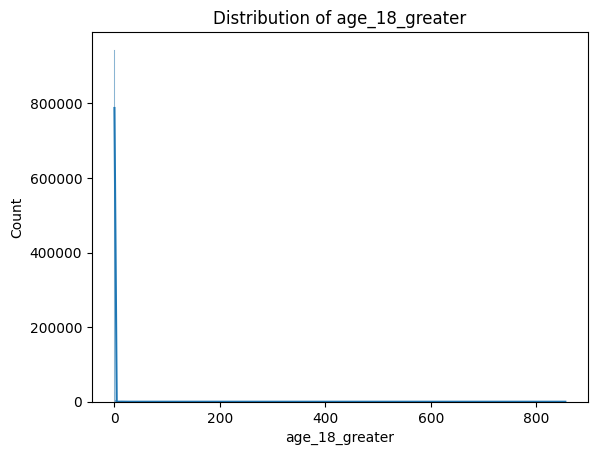

In [20]:
for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


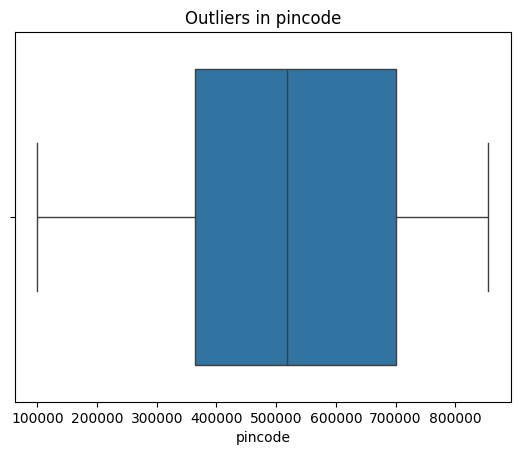

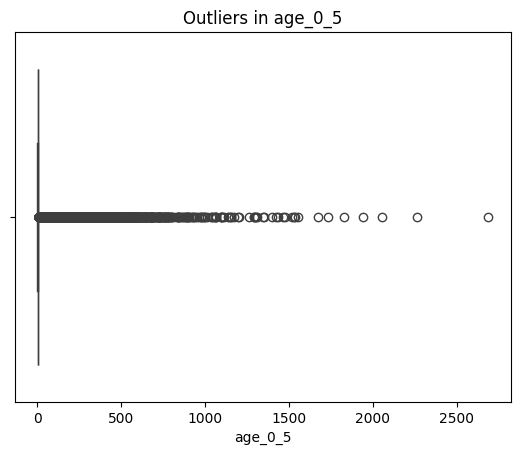

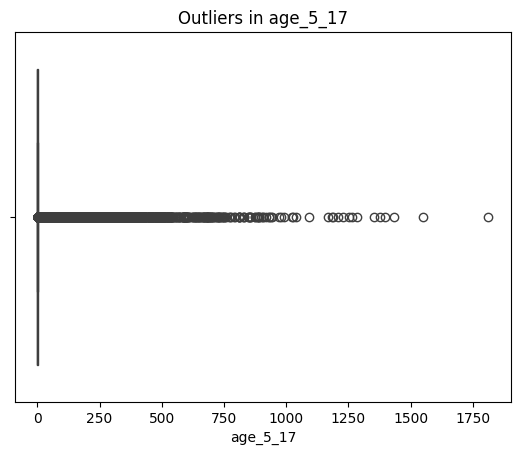

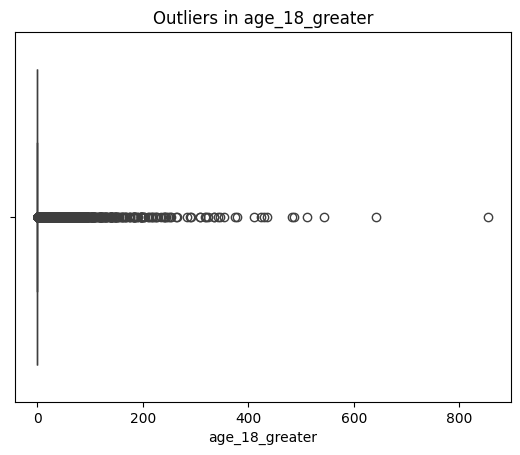

In [21]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Outliers in {col}")
    plt.show()


In [22]:
for col in cat_cols:
    print(f"\n{col}")
    print(df[col].value_counts().head(10))



date
date
15-12-2025    19326
30-10-2025    18231
22-12-2025    17905
02-11-2025    17521
19-11-2025    17335
15-11-2025    17103
17-10-2025    16924
09-09-2025    16789
08-09-2025    16768
31-12-2025    16629
Name: count, dtype: int64

state
state
Uttar Pradesh     108066
Tamil Nadu         90388
Maharashtra        75531
West Bengal        75329
Karnataka          68787
Andhra Pradesh     63832
Bihar              58542
Rajasthan          54864
Madhya Pradesh     49562
Gujarat            45243
Name: count, dtype: int64

district
district
Pune                 6515
North 24 Parganas    6404
Barddhaman           5255
Bengaluru            5216
Hyderabad            4866
Malappuram           4650
Jaipur               4562
South 24 Parganas    4507
Murshidabad          4475
K.v. Rangareddy      4450
Name: count, dtype: int64


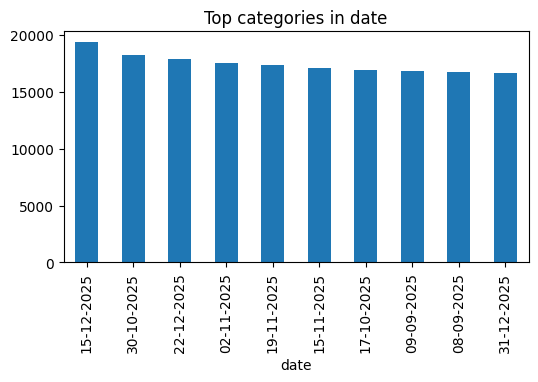

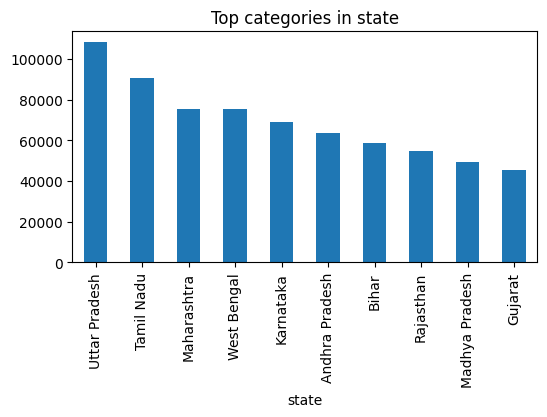

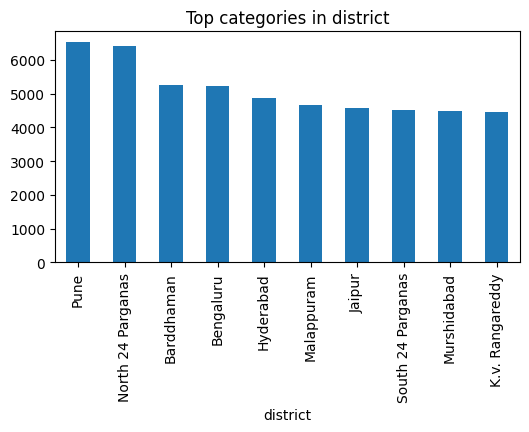

In [23]:
for col in cat_cols:
    plt.figure(figsize=(6,3))
    df[col].value_counts().head(10).plot(kind='bar')
    plt.title(f"Top categories in {col}")
    plt.show()



In [24]:
df.columns

Index(['date', 'state', 'district', 'pincode', 'age_0_5', 'age_5_17',
       'age_18_greater'],
      dtype='object')

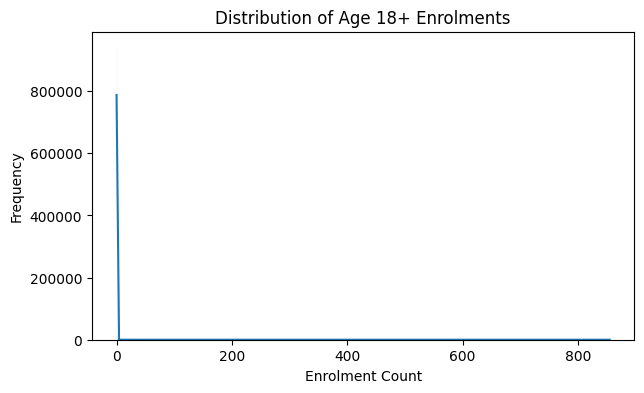

<Axes: xlabel='age_18_greater'>

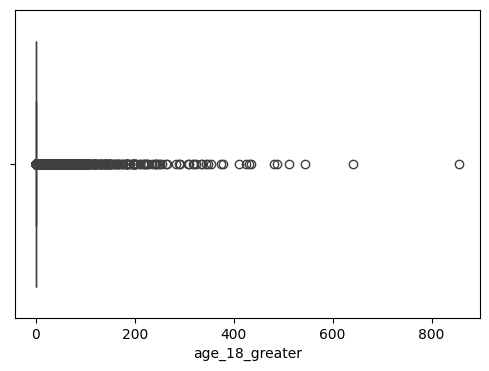

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

target = "age_18_greater"

plt.figure(figsize=(7,4))
sns.histplot(df[target], kde=True)
plt.title("Distribution of Age 18+ Enrolments")
plt.xlabel("Enrolment Count")
plt.ylabel("Frequency")
plt.show()
plt.figure(figsize=(6,4))
sns.boxplot(x=df[target])

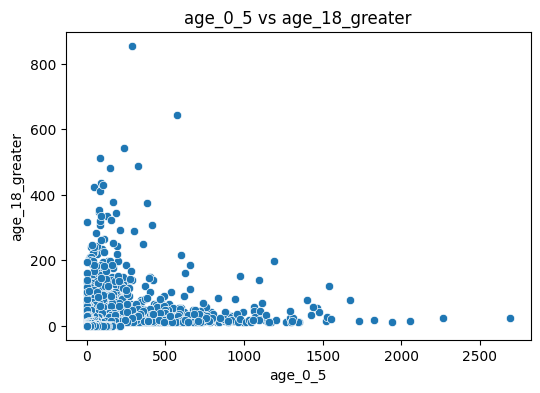

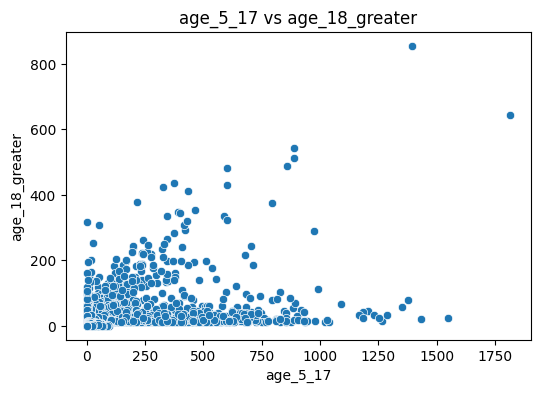

In [27]:
num_cols = ['age_0_5', 'age_5_17']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[col], y=df[target])
    plt.title(f"{col} vs {target}")
    plt.show()


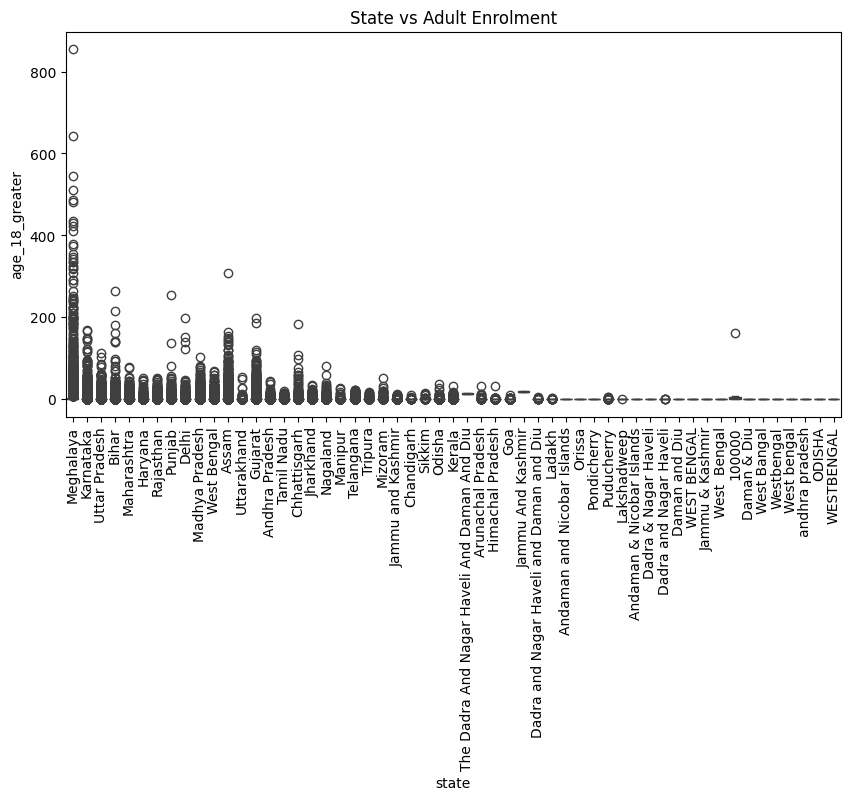

In [28]:
plt.figure(figsize=(10,5))
sns.boxplot(x='state', y=target, data=df)
plt.xticks(rotation=90)
plt.title("State vs Adult Enrolment")
plt.show()


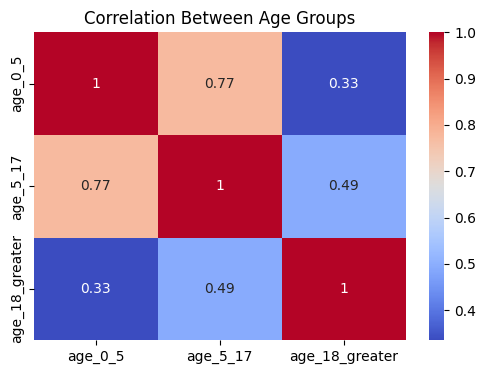

In [29]:
num_cols = ['age_0_5', 'age_5_17', 'age_18_greater']

plt.figure(figsize=(6,4))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Age Groups")
plt.show()


## features → feature engineering (date, location, ratios)

In [31]:
# Ensure datetime conversion
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Date features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['dayofweek'] = df['date'].dt.dayofweek

# SAFE week of year extraction
df['weekofyear'] = df['date'].dt.isocalendar().week.astype('Int64')


In [33]:
df['date'].isna().sum()
df.dropna(subset=['date'], inplace=True) 
 


In [35]:
# Total enrolment
df['total_enrolment'] = (
    df['age_0_5'] +
    df['age_5_17'] +
    df['age_18_greater']
)

# Avoid division by zero
df = df[df['total_enrolment'] > 0]

# Ratio features
df['ratio_0_5'] = df['age_0_5'] / df['total_enrolment']
df['ratio_5_17'] = df['age_5_17'] / df['total_enrolment']
df['ratio_18_plus'] = df['age_18_greater'] / df['total_enrolment']

# Dependency ratio
df['dependency_ratio'] = (
    df['age_0_5'] + df['age_5_17']
) / df['age_18_greater']
df['dependency_ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
df['dependency_ratio'].fillna(0, inplace=True)



In [36]:
# Sort by date (MANDATORY)
df = df.sort_values('date')

# Lag features for target
df['age_18_lag_1'] = df['age_18_greater'].shift(1)
df['age_18_lag_7'] = df['age_18_greater'].shift(7)
df['age_18_lag_30'] = df['age_18_greater'].shift(30)
df.dropna(inplace=True)  # Drop rows with NaN values from lagging

In [38]:
# Check missing values
df.isna().sum()

# Drop rows created by lag features & invalid dates
df = df.dropna().reset_index(drop=True)
df['date'].isna().sum()


np.int64(0)

In [39]:
target = "age_18_greater"

X = df.drop(columns=[
    'date',
    'state',
    'district',
    'pincode',
    target
])

y = df[target]


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (255750, 15)
Testing set shape: (63938, 15)


In [43]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")



Mean Squared Error: 0.08764297327098128
R^2 Score: 0.8975270043063633


In [44]:
df.to_csv("final_feature_dataset.csv", index=False)


In [46]:
import joblib

joblib.dump(model, "aadhaar_enrolment_model.pkl")
df['date'] = pd.to_datetime(df['date'], errors='coerce')


In [47]:
import pandas as pd

# Create importance dataframe
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by='importance',
    ascending=False
)

feature_importance.head(10)


,feature,importance
7,total_enrolment,0.387708
4,day,0.285410
11,dependency_ratio,0.103200
10,ratio_18_plus,0.086404
8,ratio_0_5,0.067408
1,age_5_17,0.054521
0,age_0_5,0.005985
9,ratio_5_17,0.003621
12,age_18_lag_1,0.001953
14,age_18_lag_30,0.001764


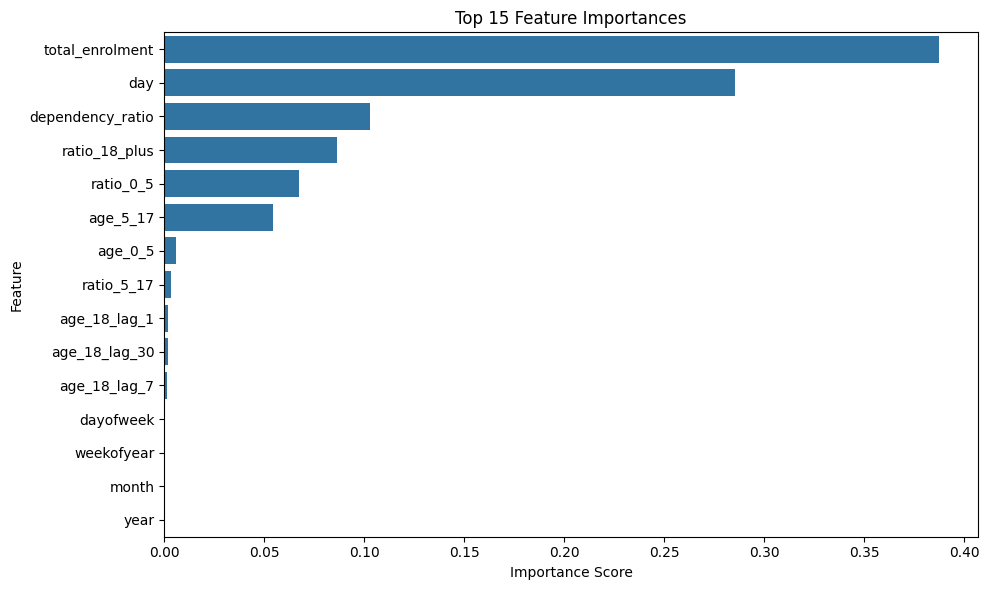

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(
    x='importance',
    y='feature',
    data=feature_importance.head(15)
)

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [49]:
feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)


In [50]:
from datetime import timedelta

def create_next_day_features(prev_row, next_date):
    row = prev_row.copy()

    # Update date features
    row['date'] = next_date
    row['year'] = next_date.year
    row['month'] = next_date.month
    row['day'] = next_date.day
    row['dayofweek'] = next_date.dayofweek
    row['weekofyear'] = next_date.isocalendar()[1]

    # Update lag features
    row['age_18_lag_30'] = row['age_18_lag_7']
    row['age_18_lag_7'] = row['age_18_lag_1']
    row['age_18_lag_1'] = row['age_18_greater']

    return row


In [52]:
future_days = 30
future_predictions = []

# Define last_row and last_date from the most recent data point in df
last_row = df.iloc[-1]
last_date = last_row['date']

current_row = last_row.copy()

for i in range(1, future_days + 1):
    next_date = last_date + timedelta(days=i)

    # Create next-day features
    next_row = create_next_day_features(current_row, next_date)

    # Prepare model input
    X_future = next_row[X.columns].values.reshape(1, -1)

    # Predict
    next_prediction = model.predict(X_future)[0]

    # Store result
    future_predictions.append({
        'date': next_date,
        'predicted_age_18_enrolment': int(next_prediction)
    })

    # Update for next iteration
    next_row['age_18_greater'] = next_prediction
    current_row = next_row


In [53]:
forecast_df = pd.DataFrame(future_predictions)
forecast_df.head()


,date,predicted_age_18_enrolment
0,2025-12-12,0
1,2025-12-13,0
2,2025-12-14,0
3,2025-12-15,0
4,2025-12-16,0


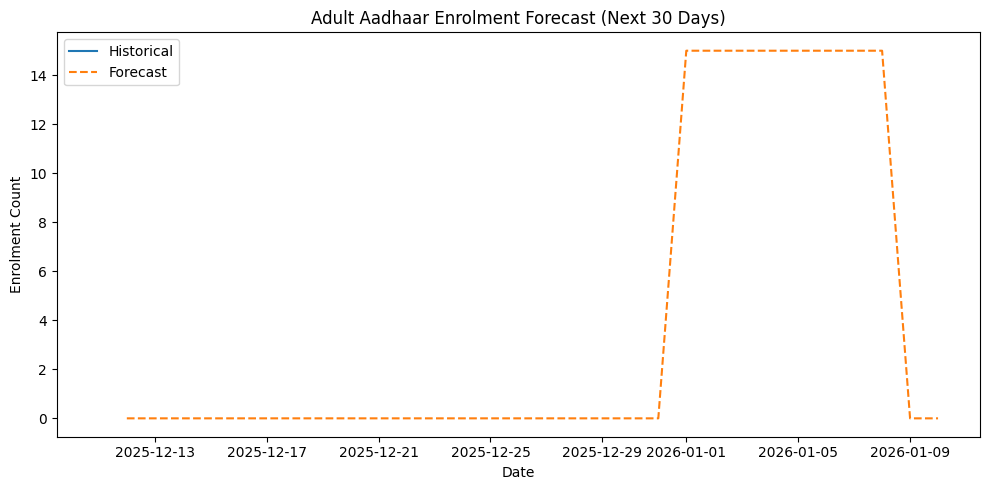

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

# Historical data (last 60 days)
plt.plot(
    df['date'].tail(60),
    df['age_18_greater'].tail(60),
    label="Historical"
)

# Forecast
plt.plot(
    forecast_df['date'],
    forecast_df['predicted_age_18_enrolment'],
    label="Forecast",
    linestyle="--"
)

plt.title("Adult Aadhaar Enrolment Forecast (Next 30 Days)")
plt.xlabel("Date")
plt.ylabel("Enrolment Count")
plt.legend()
plt.tight_layout()
plt.show()


In [55]:
forecast_df.to_csv("future_enrolment_forecast_30_days.csv", index=False)
